In [1]:
import os

print("Conteúdo de /kaggle/input:")
for item in os.listdir("/kaggle/input"):
    print("-", item)

Conteúdo de /kaggle/input:
- datasets
- notebooks


In [2]:
print("Conteúdo de /kaggle/input/datasets:")
for item in os.listdir("/kaggle/input/datasets"):
    print("-", item)

print("\nConteúdo de /kaggle/input/notebooks:")
for item in os.listdir("/kaggle/input/notebooks"):
    print("-", item)

Conteúdo de /kaggle/input/datasets:
- paultimothymooney

Conteúdo de /kaggle/input/notebooks:
- monicalanjos071829


In [3]:
print("Conteúdo do dataset de Paul Mooney:")
for item in os.listdir("/kaggle/input/datasets/paultimothymooney"):
    print("-", item)

print("\nConteúdo dos meus notebooks:")
for item in os.listdir("/kaggle/input/notebooks/monicalanjos071829"):
    print("-", item)

Conteúdo do dataset de Paul Mooney:
- chest-xray-pneumonia

Conteúdo dos meus notebooks:
- 01-verificacao-dataset-pneumonia


In [4]:
pasta_notebook_01 = "/kaggle/input/notebooks/monicalanjos071829/01-verificacao-dataset-pneumonia"

print("Conteúdo do Notebook 01:")
for item in os.listdir(pasta_notebook_01):
    print("-", item)

Conteúdo do Notebook 01:
- base_modelagem_divisao_80_10_10.csv
- inventario_imagens_auditado.csv
- __results__.html
- __notebook__.ipynb
- __output__.json
- inventario_imagens.csv
- custom.css


In [5]:
caminho_csv = os.path.join(
    pasta_notebook_01,
    "base_modelagem_divisao_80_10_10.csv"
)

print("Caminho do CSV:")
print(caminho_csv)

print("\nArquivo existe?")
print(os.path.exists(caminho_csv))

Caminho do CSV:
/kaggle/input/notebooks/monicalanjos071829/01-verificacao-dataset-pneumonia/base_modelagem_divisao_80_10_10.csv

Arquivo existe?
True


In [6]:
import pandas as pd

base_modelagem = pd.read_csv(caminho_csv)

print("Quantidade de linhas e colunas:")
print(base_modelagem.shape)

print("\nColunas encontradas:")
print(base_modelagem.columns.tolist())

Quantidade de linhas e colunas:
(5824, 11)

Colunas encontradas:
['caminho', 'nome_arquivo', 'divisao_original', 'classe', 'extensao', 'sha256', 'grupo_candidato', 'duplicata_exata', 'copia_excedente', 'fold', 'divisao_nova']


In [7]:
print("Quantidade de imagens por divisão:")
print(base_modelagem["divisao_nova"].value_counts())

Quantidade de imagens por divisão:
divisao_nova
treino       4682
teste         581
validacao     561
Name: count, dtype: int64


In [8]:
distribuicao_classes = pd.crosstab(
    base_modelagem["divisao_nova"],
    base_modelagem["classe"]
)

print("Distribuição das classes por divisão:")
print(distribuicao_classes)

Distribuição das classes por divisão:
classe        NORMAL  PNEUMONIA
divisao_nova                   
teste            166        415
treino          1259       3423
validacao        154        407


In [9]:
print("Exemplos de caminhos armazenados no CSV:")

for caminho in base_modelagem["caminho"].head(5):
    print(caminho)

Exemplos de caminhos armazenados no CSV:
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0115-0001.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0117-0001.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0119-0001.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0122-0001.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0125-0001.jpeg


In [10]:
base_modelagem["arquivo_existe"] = base_modelagem["caminho"].apply(os.path.exists)

print("Verificação dos arquivos:")
print(base_modelagem["arquivo_existe"].value_counts())

print("\nQuantidade de arquivos ausentes:")
print((~base_modelagem["arquivo_existe"]).sum())

Verificação dos arquivos:
arquivo_existe
True    5824
Name: count, dtype: int64

Quantidade de arquivos ausentes:
0


In [11]:
from PIL import Image

caminho_primeira_imagem = base_modelagem.iloc[0]["caminho"]

with Image.open(caminho_primeira_imagem) as imagem:
    print("Arquivo:", base_modelagem.iloc[0]["nome_arquivo"])
    print("Classe:", base_modelagem.iloc[0]["classe"])
    print("Formato:", imagem.format)
    print("Dimensões (largura, altura):", imagem.size)
    print("Modo de cor:", imagem.mode)

Arquivo: IM-0115-0001.jpeg
Classe: NORMAL
Formato: JPEG
Dimensões (largura, altura): (2090, 1858)
Modo de cor: L


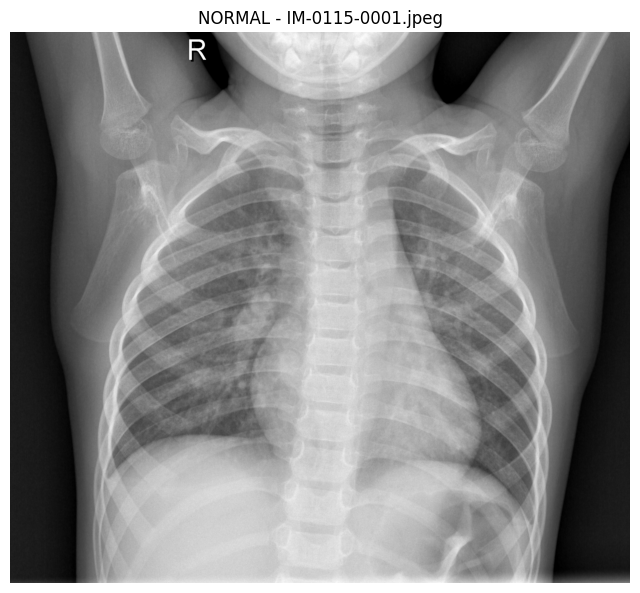

In [12]:
import matplotlib.pyplot as plt

with Image.open(caminho_primeira_imagem) as imagem:
    plt.figure(figsize=(8, 8))
    plt.imshow(imagem, cmap="gray")
    plt.title(
        f"{base_modelagem.iloc[0]['classe']} - "
        f"{base_modelagem.iloc[0]['nome_arquivo']}"
    )
    plt.axis("off")
    plt.show()

In [13]:
print("Arquivo:", base_modelagem.iloc[0]["nome_arquivo"])
print("Classe:", base_modelagem.iloc[0]["classe"])
print("Divisão original:", base_modelagem.iloc[0]["divisao_original"])
print("Divisão nova:", base_modelagem.iloc[0]["divisao_nova"])

Arquivo: IM-0115-0001.jpeg
Classe: NORMAL
Divisão original: train
Divisão nova: validacao


In [14]:
base_treino = base_modelagem[
    base_modelagem["divisao_nova"] == "treino"
].copy()

print("Quantidade de imagens no treino:")
print(len(base_treino))

print("\nDistribuição das classes no treino:")
print(base_treino["classe"].value_counts())

Quantidade de imagens no treino:
4682

Distribuição das classes no treino:
classe
PNEUMONIA    3423
NORMAL       1259
Name: count, dtype: int64


In [15]:
amostra_normal = base_treino[
    base_treino["classe"] == "NORMAL"
].sample(n=3, random_state=42)

amostra_pneumonia = base_treino[
    base_treino["classe"] == "PNEUMONIA"
].sample(n=3, random_state=42)

amostra_visual = pd.concat([
    amostra_normal,
    amostra_pneumonia
])

print("Amostra selecionada:")
print(
    amostra_visual[
        ["nome_arquivo", "classe", "divisao_nova"]
    ]
)

Amostra selecionada:
                      nome_arquivo     classe divisao_nova
100              IM-0274-0001.jpeg     NORMAL       treino
1292     NORMAL2-IM-1318-0001.jpeg     NORMAL       treino
58               IM-0220-0001.jpeg     NORMAL       treino
2314    person1462_virus_2512.jpeg  PNEUMONIA       treino
4331     person578_virus_1122.jpeg  PNEUMONIA       treino
3900  person469_bacteria_1993.jpeg  PNEUMONIA       treino


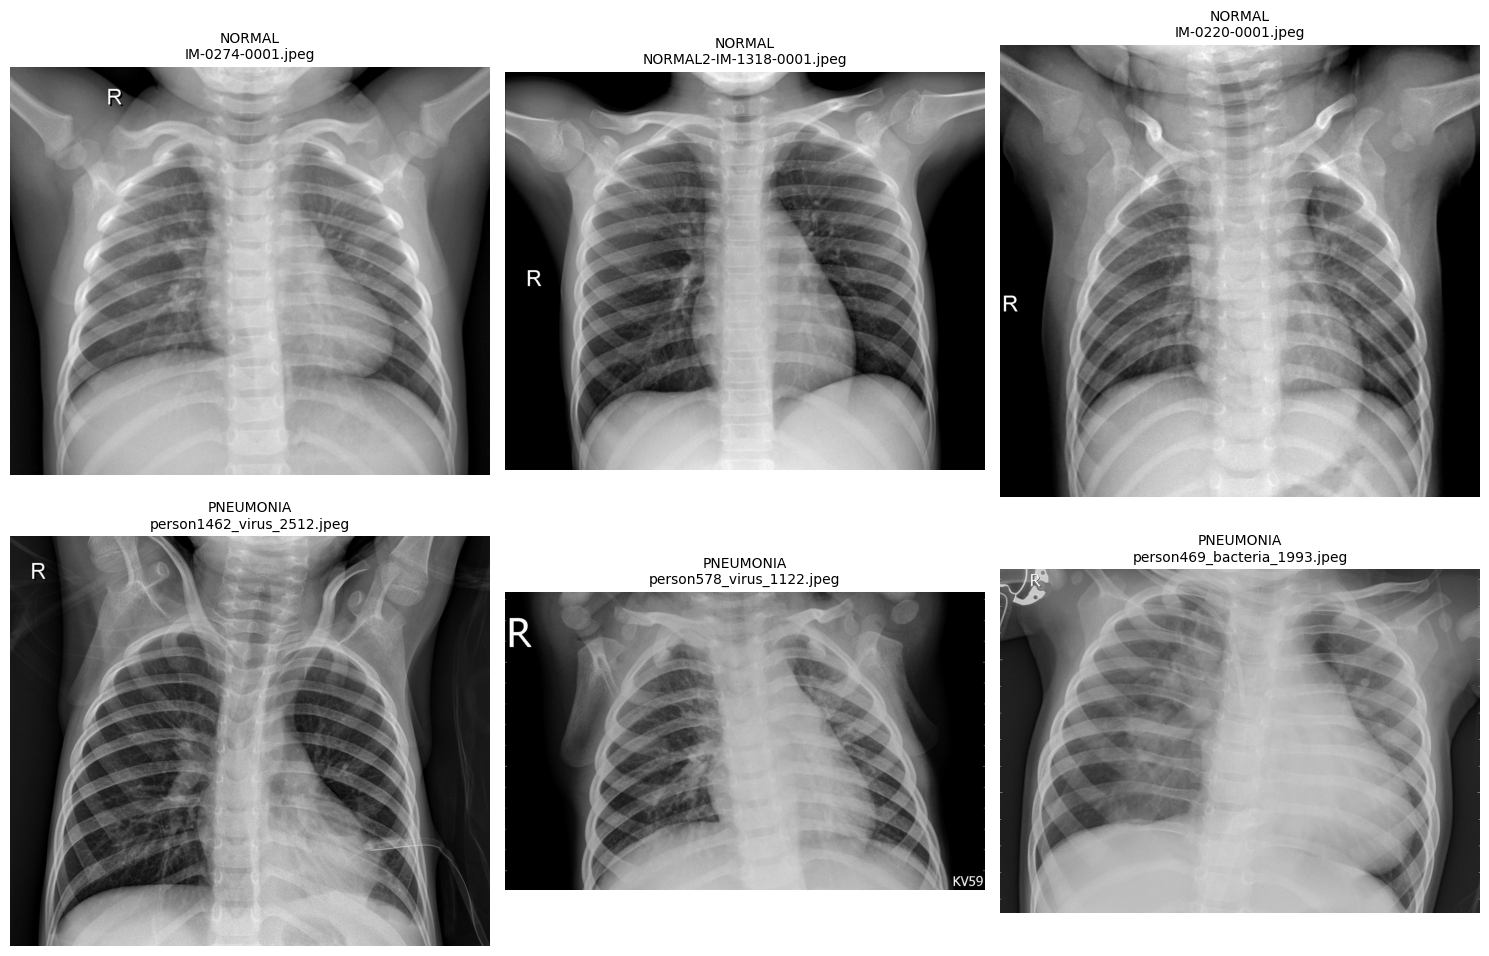

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (_, linha) in zip(axes.flat, amostra_visual.iterrows()):
    with Image.open(linha["caminho"]) as imagem:
        ax.imshow(imagem, cmap="gray")

    ax.set_title(
        f"{linha['classe']}\n{linha['nome_arquivo']}",
        fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
larguras = []
alturas = []
modos_cor = []

for caminho in base_treino["caminho"]:
    with Image.open(caminho) as imagem:
        largura, altura = imagem.size

        larguras.append(largura)
        alturas.append(altura)
        modos_cor.append(imagem.mode)

print("Imagens analisadas:", len(larguras))
print("Larguras coletadas:", len(larguras))
print("Alturas coletadas:", len(alturas))
print("Modos de cor coletados:", len(modos_cor))

Imagens analisadas: 4682
Larguras coletadas: 4682
Alturas coletadas: 4682
Modos de cor coletados: 4682


In [18]:
base_treino["largura"] = larguras
base_treino["altura"] = alturas
base_treino["modo_cor"] = modos_cor

print("Dimensões da base_treino após adicionar as novas colunas:")
print(base_treino.shape)

print("\nNovas colunas:")
print(
    base_treino[
        ["nome_arquivo", "classe", "largura", "altura", "modo_cor"]
    ].head()
)

Dimensões da base_treino após adicionar as novas colunas:
(4682, 15)

Novas colunas:
        nome_arquivo  classe  largura  altura modo_cor
1  IM-0117-0001.jpeg  NORMAL     1422    1152        L
3  IM-0122-0001.jpeg  NORMAL     1618    1279        L
4  IM-0125-0001.jpeg  NORMAL     1600    1125        L
5  IM-0127-0001.jpeg  NORMAL     1974    1306        L
6  IM-0128-0001.jpeg  NORMAL     1528    1013        L


In [19]:
resumo_dimensoes = base_treino[
    ["largura", "altura"]
].agg(["min", "mean", "median", "max"])

print("Resumo das dimensões:")
print(resumo_dimensoes.round(2))

print("\nModos de cor encontrados:")
print(base_treino["modo_cor"].value_counts())

Resumo das dimensões:
        largura   altura
min       384.0   127.00
mean     1323.6   967.58
median   1280.0   882.00
max      2916.0  2713.00

Modos de cor encontrados:
modo_cor
L      4451
RGB     231
Name: count, dtype: int64


In [20]:
distribuicao_modo_cor = pd.crosstab(
    base_treino["classe"],
    base_treino["modo_cor"]
)

print("Distribuição do modo de cor por classe:")
print(distribuicao_modo_cor)

Distribuição do modo de cor por classe:
modo_cor      L  RGB
classe              
NORMAL     1259    0
PNEUMONIA  3192  231


In [21]:
import numpy as np

base_rgb = base_treino[
    base_treino["modo_cor"] == "RGB"
].copy()

canais_identicos = 0
canais_diferentes = 0

for caminho in base_rgb["caminho"]:
    with Image.open(caminho) as imagem:
        array_imagem = np.array(imagem)

    r = array_imagem[:, :, 0]
    g = array_imagem[:, :, 1]
    b = array_imagem[:, :, 2]

    if np.array_equal(r, g) and np.array_equal(g, b):
        canais_identicos += 1
    else:
        canais_diferentes += 1

print("Imagens RGB analisadas:", len(base_rgb))
print("RGB com canais idênticos:", canais_identicos)
print("RGB com canais diferentes:", canais_diferentes)

Imagens RGB analisadas: 231
RGB com canais idênticos: 231
RGB com canais diferentes: 0


In [22]:
base_treino["razao_aspecto"] = (
    base_treino["largura"] / base_treino["altura"]
)

print("Resumo geral da razão de aspecto:")
print(
    base_treino["razao_aspecto"]
    .agg(["min", "mean", "median", "max"])
    .round(3)
)

print("\nRazão de aspecto por classe:")
print(
    base_treino.groupby("classe")["razao_aspecto"]
    .agg(["min", "mean", "median", "max"])
    .round(3)
)

Resumo geral da razão de aspecto:
min       0.835
mean      1.443
median    1.416
max       3.379
Name: razao_aspecto, dtype: float64

Razão de aspecto por classe:
             min   mean  median    max
classe                                
NORMAL     0.888  1.248   1.233  2.034
PNEUMONIA  0.835  1.514   1.488  3.379


In [23]:
colunas_extremos = [
    "nome_arquivo",
    "classe",
    "largura",
    "altura",
    "razao_aspecto"
]

print("5 menores razões de aspecto:")
print(
    base_treino
    .nsmallest(5, "razao_aspecto")[colunas_extremos]
    .round(3)
)

print("\n5 maiores razões de aspecto:")
print(
    base_treino
    .nlargest(5, "razao_aspecto")[colunas_extremos]
    .round(3)
)

5 menores razões de aspecto:
                        nome_arquivo     classe  largura  altura  \
1605      person1147_virus_1917.jpeg  PNEUMONIA     1624    1944   
1064       NORMAL2-IM-1038-0001.jpeg     NORMAL     2309    2601   
1163       NORMAL2-IM-1160-0001.jpeg     NORMAL     2091    2326   
1031  NORMAL2-IM-0995-0001-0002.jpeg     NORMAL     1692    1878   
738        NORMAL2-IM-0567-0001.jpeg     NORMAL     1962    2169   

      razao_aspecto  
1605          0.835  
1064          0.888  
1163          0.899  
1031          0.901  
738           0.905  

5 maiores razões de aspecto:
                       nome_arquivo     classe  largura  altura  razao_aspecto
3331       person325_virus_661.jpeg  PNEUMONIA      446     132          3.379
2754  person1684_bacteria_4462.jpeg  PNEUMONIA      494     151          3.272
3329       person325_virus_659.jpeg  PNEUMONIA      445     140          3.179
2817  person1732_bacteria_4564.jpeg  PNEUMONIA      492     156          3.154
3658 

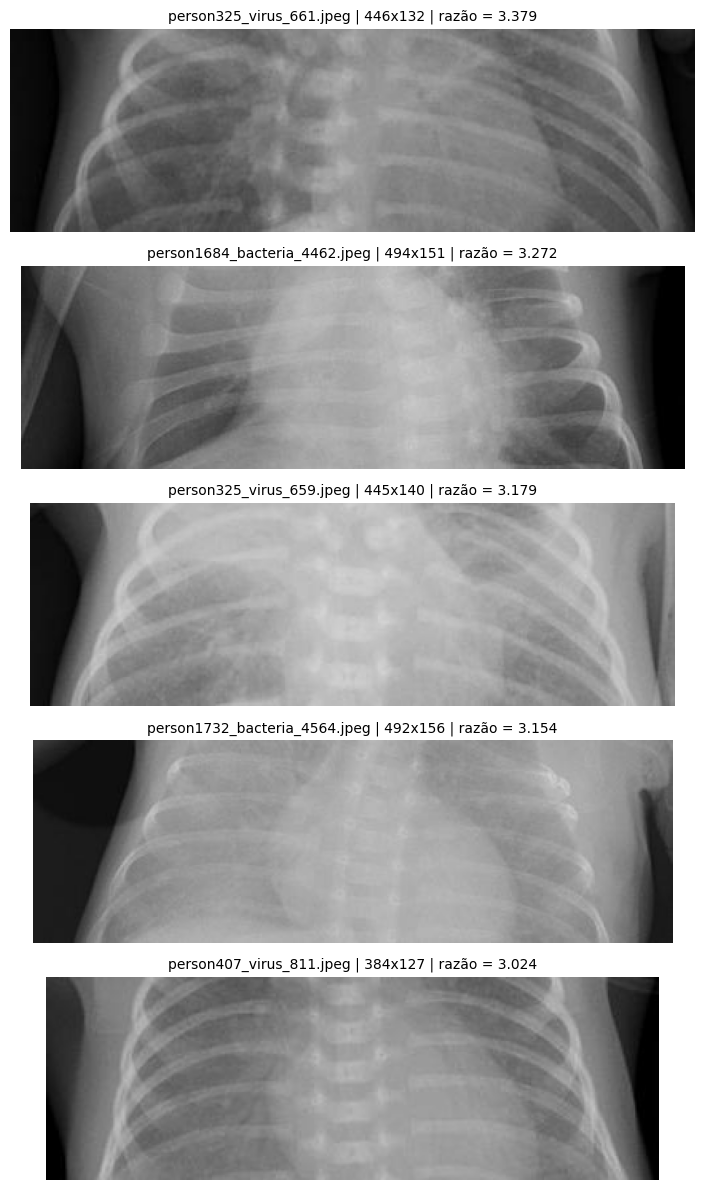

In [24]:
imagens_aspecto_alto = base_treino.nlargest(
    5,
    "razao_aspecto"
)

fig, axes = plt.subplots(5, 1, figsize=(12, 12))

for ax, (_, linha) in zip(
    axes,
    imagens_aspecto_alto.iterrows()
):
    with Image.open(linha["caminho"]) as imagem:
        ax.imshow(imagem, cmap="gray")

    ax.set_title(
        f"{linha['nome_arquivo']} | "
        f"{linha['largura']}x{linha['altura']} | "
        f"razão = {linha['razao_aspecto']:.3f}",
        fontsize=10
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
print("Imagens com razão de aspecto > 2.0:")
print((base_treino["razao_aspecto"] > 2.0).sum())

print("\nImagens com razão de aspecto > 2.5:")
print((base_treino["razao_aspecto"] > 2.5).sum())

print("\nImagens com razão de aspecto > 3.0:")
print((base_treino["razao_aspecto"] > 3.0).sum())

Imagens com razão de aspecto > 2.0:
96

Imagens com razão de aspecto > 2.5:
21

Imagens com razão de aspecto > 3.0:
5


In [26]:
for limite in [2.0, 2.5, 3.0]:
    imagens_extremas = base_treino[
        base_treino["razao_aspecto"] > limite
    ]

    print(f"Razão de aspecto > {limite}:")
    print(imagens_extremas["classe"].value_counts())
    print()

Razão de aspecto > 2.0:
classe
PNEUMONIA    95
NORMAL        1
Name: count, dtype: int64

Razão de aspecto > 2.5:
classe
PNEUMONIA    21
Name: count, dtype: int64

Razão de aspecto > 3.0:
classe
PNEUMONIA    5
Name: count, dtype: int64



In [27]:
for limite in [2.0, 2.5, 3.0]:
    print(f"Razão de aspecto > {limite}:")

    for classe in ["NORMAL", "PNEUMONIA"]:
        dados_classe = base_treino[
            base_treino["classe"] == classe
        ]

        quantidade = (
            dados_classe["razao_aspecto"] > limite
        ).sum()

        percentual = (
            quantidade / len(dados_classe)
        ) * 100

        print(
            f"{classe}: {quantidade} imagens "
            f"({percentual:.2f}%)"
        )

    print()

Razão de aspecto > 2.0:
NORMAL: 1 imagens (0.08%)
PNEUMONIA: 95 imagens (2.78%)

Razão de aspecto > 2.5:
NORMAL: 0 imagens (0.00%)
PNEUMONIA: 21 imagens (0.61%)

Razão de aspecto > 3.0:
NORMAL: 0 imagens (0.00%)
PNEUMONIA: 5 imagens (0.15%)



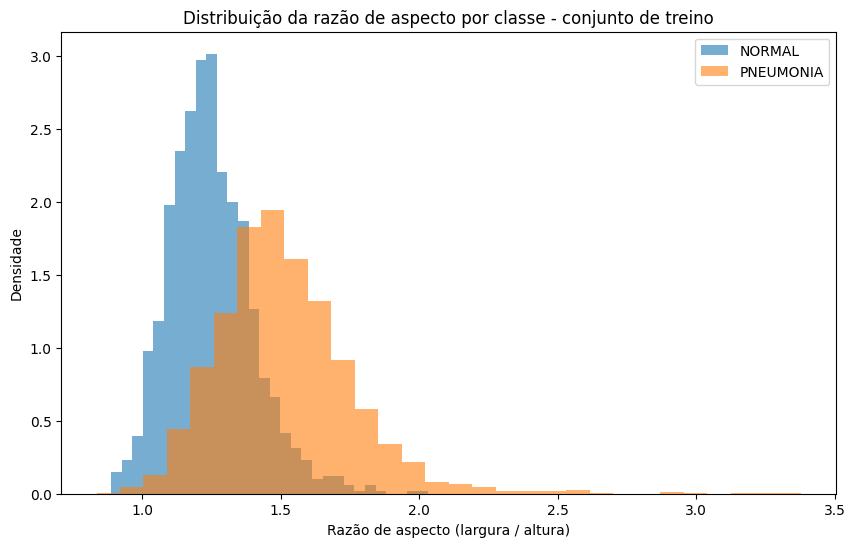

In [28]:
plt.figure(figsize=(10, 6))

for classe in ["NORMAL", "PNEUMONIA"]:
    dados = base_treino[
        base_treino["classe"] == classe
    ]["razao_aspecto"]

    plt.hist(
        dados,
        bins=30,
        alpha=0.6,
        label=classe,
        density=True
    )

plt.xlabel("Razão de aspecto (largura / altura)")
plt.ylabel("Densidade")
plt.title("Distribuição da razão de aspecto por classe - conjunto de treino")
plt.legend()

plt.show()

In [29]:
percentis_razao = (
    base_treino
    .groupby("classe")["razao_aspecto"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95])
    .unstack()
)

percentis_razao.columns = [
    "P25",
    "P50_mediana",
    "P75",
    "P90",
    "P95"
]

print("Percentis da razão de aspecto por classe:")
print(percentis_razao.round(3))

Percentis da razão de aspecto por classe:
             P25  P50_mediana    P75    P90    P95
classe                                            
NORMAL     1.143        1.233  1.336  1.438  1.513
PNEUMONIA  1.354        1.488  1.645  1.800  1.914


In [30]:
resumo_dimensoes_classe = (
    base_treino
    .groupby("classe")[["largura", "altura"]]
    .agg(["min", "mean", "median", "max"])
    .round(2)
)

print("Resumo das dimensões por classe:")
print(resumo_dimensoes_classe)

Resumo das dimensões por classe:
          largura                        altura                       
              min     mean  median   max    min     mean  median   max
classe                                                                
NORMAL        912  1678.13  1644.0  2916    496  1372.17  1319.0  2713
PNEUMONIA     384  1193.20  1160.0  2772    127   818.77   768.0  2304


In [31]:
base_treino["pixels_totais"] = (
    base_treino["largura"] * base_treino["altura"]
)

resumo_pixels = (
    base_treino
    .groupby("classe")["pixels_totais"]
    .agg(["min", "mean", "median", "max"])
)

print("Resumo da quantidade total de pixels por classe:")
print(resumo_pixels.round(0))

Resumo da quantidade total de pixels por classe:
              min       mean     median      max
classe                                          
NORMAL     488064  2388811.0  2167074.0  7532028
PNEUMONIA   48768  1047007.0   893760.0  5815656


In [32]:
percentis_pixels = (
    base_treino
    .groupby("classe")["pixels_totais"]
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
    .unstack()
)

percentis_pixels.columns = [
    "P10",
    "P25",
    "P50_mediana",
    "P75",
    "P90"
]

print("Percentis da quantidade total de pixels por classe:")
print(percentis_pixels.round(0))

Percentis da quantidade total de pixels por classe:
                 P10        P25  P50_mediana        P75        P90
classe                                                            
NORMAL     1386346.0  1686566.0    2167074.0  2784372.0  3721178.0
PNEUMONIA   496358.0   638720.0     893760.0  1283599.0  1815526.0


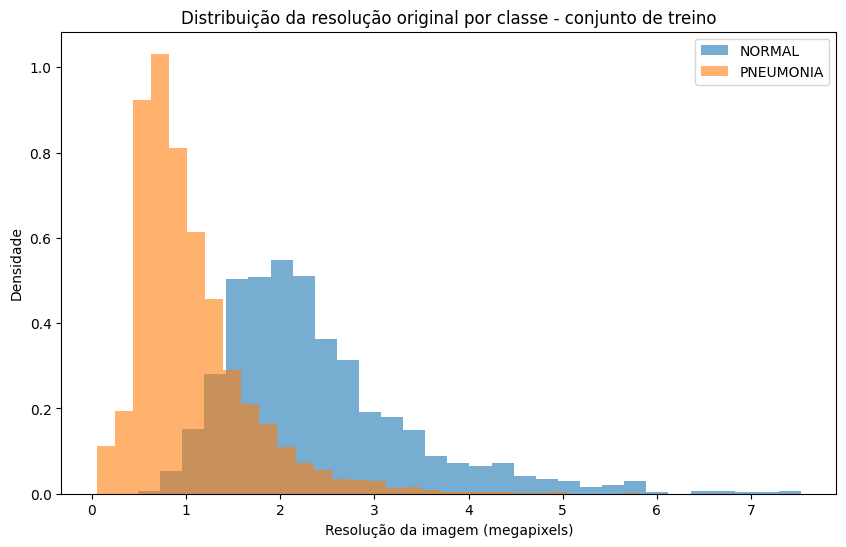

In [33]:
base_treino["megapixels"] = (
    base_treino["pixels_totais"] / 1_000_000
)

plt.figure(figsize=(10, 6))

for classe in ["NORMAL", "PNEUMONIA"]:
    dados = base_treino[
        base_treino["classe"] == classe
    ]["megapixels"]

    plt.hist(
        dados,
        bins=30,
        alpha=0.6,
        label=classe,
        density=True
    )

plt.xlabel("Resolução da imagem (megapixels)")
plt.ylabel("Densidade")
plt.title(
    "Distribuição da resolução original por classe - conjunto de treino"
)
plt.legend()

plt.show()

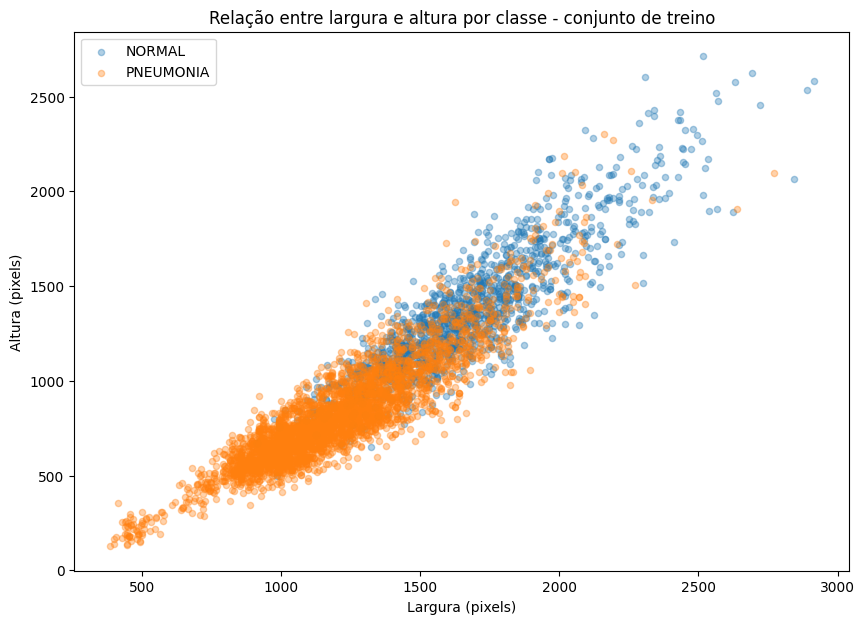

In [34]:
plt.figure(figsize=(10, 7))

for classe in ["NORMAL", "PNEUMONIA"]:
    dados = base_treino[
        base_treino["classe"] == classe
    ]

    plt.scatter(
        dados["largura"],
        dados["altura"],
        alpha=0.35,
        label=classe,
        s=20
    )

plt.xlabel("Largura (pixels)")
plt.ylabel("Altura (pixels)")
plt.title(
    "Relação entre largura e altura por classe - conjunto de treino"
)
plt.legend()

plt.show()

In [35]:
for classe in ["NORMAL", "PNEUMONIA"]:
    dimensoes_frequentes = (
        base_treino[
            base_treino["classe"] == classe
        ]
        .groupby(["largura", "altura"])
        .size()
        .sort_values(ascending=False)
        .head(10)
    )

    print(f"10 dimensões mais frequentes - {classe}:")
    print(dimensoes_frequentes)
    print()

10 dimensões mais frequentes - NORMAL:
largura  altura
1624     1341      2
1962     2169      2
1450     1210      2
1472     1171      2
1558     1279      2
1596     1306      2
1968     1484      2
1766     1380      1
         1349      1
         1287      1
dtype: int64

10 dimensões mais frequentes - PNEUMONIA:
largura  altura
1080     728       6
1072     648       6
1008     704       6
992      608       5
1000     704       5
992      592       5
1192     760       5
976      672       5
1064     760       5
1000     568       4
dtype: int64



In [36]:
for classe in ["NORMAL", "PNEUMONIA"]:
    dados_classe = base_treino[
        base_treino["classe"] == classe
    ]

    total_imagens = len(dados_classe)

    dimensoes_unicas = (
        dados_classe[
            ["largura", "altura"]
        ]
        .drop_duplicates()
        .shape[0]
    )

    contagem_dimensoes = (
        dados_classe
        .groupby(["largura", "altura"])
        .size()
    )

    imagens_em_dimensoes_repetidas = (
        contagem_dimensoes[
            contagem_dimensoes > 1
        ].sum()
    )

    percentual_repetidas = (
        imagens_em_dimensoes_repetidas
        / total_imagens
    ) * 100

    print(f"{classe}:")
    print("Total de imagens:", total_imagens)
    print("Dimensões únicas:", dimensoes_unicas)
    print(
        "Imagens cuja dimensão exata se repete:",
        imagens_em_dimensoes_repetidas
    )
    print(
        f"Percentual em dimensões repetidas: "
        f"{percentual_repetidas:.2f}%"
    )
    print()

NORMAL:
Total de imagens: 1259
Dimensões únicas: 1252
Imagens cuja dimensão exata se repete: 14
Percentual em dimensões repetidas: 1.11%

PNEUMONIA:
Total de imagens: 3423
Dimensões únicas: 2747
Imagens cuja dimensão exata se repete: 1177
Percentual em dimensões repetidas: 34.39%



In [37]:
for classe in ["NORMAL", "PNEUMONIA"]:
    contagem_dimensoes = (
        base_treino[
            base_treino["classe"] == classe
        ]
        .groupby(["largura", "altura"])
        .size()
    )

    grupos_repetidos = contagem_dimensoes[
        contagem_dimensoes > 1
    ]

    print(f"{classe}:")
    print(
        "Quantidade de dimensões que se repetem:",
        len(grupos_repetidos)
    )

    if len(grupos_repetidos) > 0:
        print(
            "Maior número de imagens com a mesma dimensão:",
            grupos_repetidos.max()
        )

        print("Distribuição dos tamanhos dos grupos repetidos:")
        print(
            grupos_repetidos
            .value_counts()
            .sort_index()
        )

    print()

NORMAL:
Quantidade de dimensões que se repetem: 7
Maior número de imagens com a mesma dimensão: 2
Distribuição dos tamanhos dos grupos repetidos:
2    7
Name: count, dtype: int64

PNEUMONIA:
Quantidade de dimensões que se repetem: 501
Maior número de imagens com a mesma dimensão: 6
Distribuição dos tamanhos dos grupos repetidos:
2    371
3     97
4     24
5      6
6      3
Name: count, dtype: int64



In [38]:
dimensoes_repetidas_pneumonia = (
    base_treino[
        base_treino["classe"] == "PNEUMONIA"
    ]
    .groupby(["largura", "altura"])
    .agg(
        n_imagens=("nome_arquivo", "size"),
        n_grupos=("grupo_candidato", "nunique")
    )
    .reset_index()
)

dimensoes_repetidas_pneumonia = (
    dimensoes_repetidas_pneumonia[
        dimensoes_repetidas_pneumonia["n_imagens"] > 1
    ]
    .copy()
)

um_grupo = (
    dimensoes_repetidas_pneumonia["n_grupos"] == 1
)

print(
    "Combinações de dimensão repetidas:",
    len(dimensoes_repetidas_pneumonia)
)

print(
    "Restritas a um único grupo candidato:",
    um_grupo.sum()
)

print(
    "Presentes em múltiplos grupos candidatos:",
    (~um_grupo).sum()
)

print("\nQuantidade de imagens nessas combinações:")

print(
    "Em dimensões restritas a um único grupo:",
    dimensoes_repetidas_pneumonia.loc[
        um_grupo, "n_imagens"
    ].sum()
)

print(
    "Em dimensões presentes em múltiplos grupos:",
    dimensoes_repetidas_pneumonia.loc[
        ~um_grupo, "n_imagens"
    ].sum()
)

Combinações de dimensão repetidas: 501
Restritas a um único grupo candidato: 0
Presentes em múltiplos grupos candidatos: 501

Quantidade de imagens nessas combinações:
Em dimensões restritas a um único grupo: 0
Em dimensões presentes em múltiplos grupos: 1177


In [39]:
medias_intensidade = []
desvios_intensidade = []

for caminho in base_treino["caminho"]:
    with Image.open(caminho) as imagem:
        imagem_cinza = imagem.convert("L")
        array_imagem = np.array(imagem_cinza)

        medias_intensidade.append(array_imagem.mean())
        desvios_intensidade.append(array_imagem.std())

print("Imagens analisadas:", len(medias_intensidade))
print("Médias coletadas:", len(medias_intensidade))
print("Desvios coletados:", len(desvios_intensidade))

Imagens analisadas: 4682
Médias coletadas: 4682
Desvios coletados: 4682


In [40]:
base_treino["intensidade_media"] = medias_intensidade
base_treino["desvio_intensidade"] = desvios_intensidade

print("Dimensões atuais da base_treino:")
print(base_treino.shape)

print("\nExemplos das novas medidas:")
print(
    base_treino[
        [
            "nome_arquivo",
            "classe",
            "intensidade_media",
            "desvio_intensidade"
        ]
    ]
    .head()
    .round(2)
)

Dimensões atuais da base_treino:
(4682, 20)

Exemplos das novas medidas:
        nome_arquivo  classe  intensidade_media  desvio_intensidade
1  IM-0117-0001.jpeg  NORMAL             100.65               59.81
3  IM-0122-0001.jpeg  NORMAL             132.99               64.97
4  IM-0125-0001.jpeg  NORMAL             106.22               65.09
5  IM-0127-0001.jpeg  NORMAL             130.38               57.09
6  IM-0128-0001.jpeg  NORMAL              97.20               58.82


In [41]:
resumo_intensidade = (
    base_treino
    .groupby("classe")[
        ["intensidade_media", "desvio_intensidade"]
    ]
    .agg(["min", "mean", "median", "max"])
    .round(2)
)

print("Resumo de intensidade e variação tonal por classe:")
print(resumo_intensidade)

Resumo de intensidade e variação tonal por classe:
          intensidade_media                         desvio_intensidade         \
                        min    mean  median     max                min   mean   
classe                                                                          
NORMAL                73.30  122.48  122.33  169.64              38.17  61.27   
PNEUMONIA             58.72  122.84  122.91  221.54              20.42  55.26   

                         
          median    max  
classe                   
NORMAL     61.55  83.10  
PNEUMONIA  54.58  87.48  


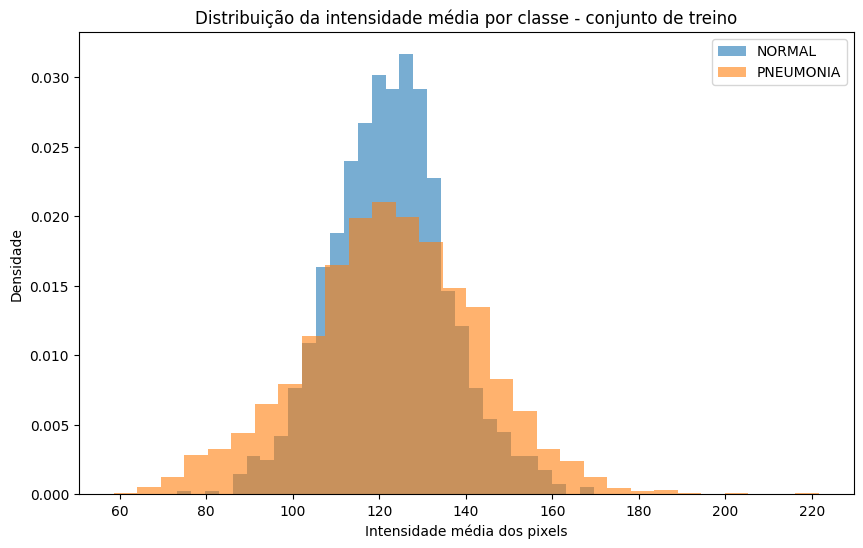

In [42]:
plt.figure(figsize=(10, 6))

for classe in ["NORMAL", "PNEUMONIA"]:
    dados = base_treino[
        base_treino["classe"] == classe
    ]["intensidade_media"]

    plt.hist(
        dados,
        bins=30,
        alpha=0.6,
        label=classe,
        density=True
    )

plt.xlabel("Intensidade média dos pixels")
plt.ylabel("Densidade")
plt.title(
    "Distribuição da intensidade média por classe - conjunto de treino"
)
plt.legend()

plt.show()

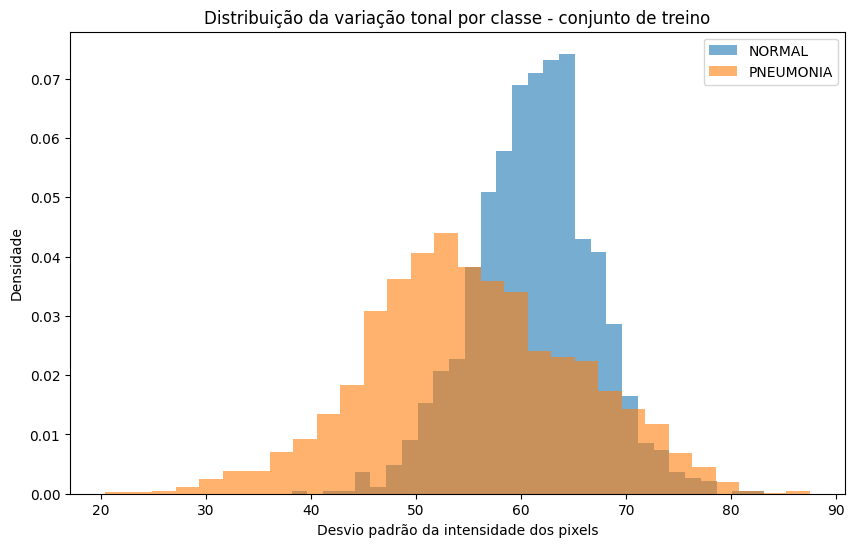

In [43]:
plt.figure(figsize=(10, 6))

for classe in ["NORMAL", "PNEUMONIA"]:
    dados = base_treino[
        base_treino["classe"] == classe
    ]["desvio_intensidade"]

    plt.hist(
        dados,
        bins=30,
        alpha=0.6,
        label=classe,
        density=True
    )

plt.xlabel("Desvio padrão da intensidade dos pixels")
plt.ylabel("Densidade")
plt.title(
    "Distribuição da variação tonal por classe - conjunto de treino"
)
plt.legend()

plt.show()

## Síntese da análise exploratória das imagens de treino

A análise exploratória foi realizada exclusivamente sobre o conjunto de treino da divisão experimental oficial, composto por 4.682 imagens.

### Principais observações

- Todas as 4.682 imagens de treino foram localizadas e abertas corretamente.
- As imagens apresentam grande heterogeneidade de resolução original.
- A largura variou de 384 a 2.916 pixels e a altura de 127 a 2.713 pixels.
- As classes apresentam diferenças sistemáticas de resolução:
  - NORMAL: mediana de 1.644 × 1.319 pixels.
  - PNEUMONIA: mediana de 1.160 × 768 pixels.
- A mediana da quantidade total de pixels foi aproximadamente:
  - NORMAL: 2,17 megapixels.
  - PNEUMONIA: 0,89 megapixel.
- A razão de aspecto também apresentou distribuições diferentes:
  - NORMAL: mediana de 1,233.
  - PNEUMONIA: mediana de 1,488.
- Imagens com razão de aspecto muito elevada foram raras, porém concentradas principalmente na classe PNEUMONIA.
- Foram observadas radiografias com diferentes enquadramentos, bordas e marcadores textuais, incluindo marcadores de lateralidade.
- Foram encontradas 4.451 imagens armazenadas em modo L e 231 em RGB.
- Todas as imagens RGB pertencem à classe PNEUMONIA, porém seus canais R, G e B são exatamente idênticos, indicando ausência de informação cromática real.
- A intensidade média dos pixels apresentou distribuições bastante semelhantes entre as classes.
- A variação tonal global, medida pelo desvio padrão dos pixels, foi maior em NORMAL, embora exista ampla sobreposição entre as distribuições.
- As diferenças geométricas, de resolução e de enquadramento podem constituir potenciais fatores de confusão e devem ser consideradas na preparação das imagens e na interpretação dos modelos.

### Implicação metodológica

As características técnicas identificadas reforçam a necessidade de utilizar um pré-processamento consistente entre as classes e de analisar posteriormente, por meio de técnicas como Grad-CAM, se os modelos concentram sua atenção em regiões anatomicamente relevantes ou em artefatos e características de aquisição.

## Estratégia definida para preparação das imagens

Com base na análise exploratória, foi definida a seguinte estratégia para a preparação dos dados:

- tamanho de entrada padronizado em 224 × 224 pixels;
- utilização de 3 canais para compatibilidade com a ResNet50;
- redimensionamento consistente de todas as imagens para o mesmo tamanho;
- CNN baseline treinada do zero com intensidades normalizadas para a faixa 0–1;
- ResNet50 utilizando o pré-processamento específico da arquitetura;
- Data Augmentation aplicado exclusivamente ao conjunto de treino;
- validação e teste sem Data Augmentation;
- manutenção integral da divisão experimental definida anteriormente: 4.682 imagens de treino, 561 de validação e 581 de teste;
- nenhum novo sorteio ou divisão dos dados será realizado.

A opção pelo redimensionamento para 224 × 224 simplifica a padronização e permite utilizar a mesma resolução espacial nos modelos comparados. Como a análise exploratória identificou diferenças sistemáticas de razão de aspecto entre as classes, estratégias baseadas em padding poderiam preservar explicitamente características geométricas associadas ao rótulo. O redimensionamento direto também possui limitações, pois pode introduzir deformação geométrica, sendo essa uma limitação metodológica a ser considerada na análise dos resultados.

A inspeção posterior com Grad-CAM será utilizada para investigar se os modelos concentram sua atenção em regiões relevantes da radiografia ou em artefatos e características técnicas do dataset.

In [44]:
import sys
import sklearn
import tensorflow as tf
import PIL
import matplotlib

print("Versões do ambiente:")
print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Pillow:", PIL.__version__)
print("Matplotlib:", matplotlib.__version__)

Versões do ambiente:
Python: 3.12.13
TensorFlow: 2.20.0
pandas: 2.3.3
NumPy: 2.0.2
scikit-learn: 1.6.1
Pillow: 11.3.0
Matplotlib: 3.10.0


In [45]:
base_validacao = base_modelagem[
    base_modelagem["divisao_nova"] == "validacao"
].copy()

base_teste = base_modelagem[
    base_modelagem["divisao_nova"] == "teste"
].copy()

print("Quantidade de imagens por conjunto:")
print("Treino:", len(base_treino))
print("Validação:", len(base_validacao))
print("Teste:", len(base_teste))

print("\nTotal:")
print(
    len(base_treino)
    + len(base_validacao)
    + len(base_teste)
)

Quantidade de imagens por conjunto:
Treino: 4682
Validação: 561
Teste: 581

Total:
5824


In [46]:
mapa_classes = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

dados_treino = base_treino[
    ["caminho", "classe"]
].copy()

dados_validacao = base_validacao[
    ["caminho", "classe"]
].copy()

dados_teste = base_teste[
    ["caminho", "classe"]
].copy()

dados_treino["rotulo"] = dados_treino["classe"].map(mapa_classes)
dados_validacao["rotulo"] = dados_validacao["classe"].map(mapa_classes)
dados_teste["rotulo"] = dados_teste["classe"].map(mapa_classes)

print("Mapeamento das classes:")
print(mapa_classes)

print("\nTreino:")
print(pd.crosstab(dados_treino["classe"], dados_treino["rotulo"]))

print("\nValidação:")
print(pd.crosstab(dados_validacao["classe"], dados_validacao["rotulo"]))

print("\nTeste:")
print(pd.crosstab(dados_teste["classe"], dados_teste["rotulo"]))

Mapeamento das classes:
{'NORMAL': 0, 'PNEUMONIA': 1}

Treino:
rotulo        0     1
classe               
NORMAL     1259     0
PNEUMONIA     0  3423

Validação:
rotulo       0    1
classe             
NORMAL     154    0
PNEUMONIA    0  407

Teste:
rotulo       0    1
classe             
NORMAL     166    0
PNEUMONIA    0  415


In [47]:
ALTURA_IMG = 224
LARGURA_IMG = 224

def carregar_e_redimensionar_imagem(caminho):
    conteudo = tf.io.read_file(caminho)

    imagem = tf.io.decode_jpeg(
        conteudo,
        channels=3
    )

    imagem = tf.image.resize(
        imagem,
        [ALTURA_IMG, LARGURA_IMG]
    )

    imagem = tf.cast(
        imagem,
        tf.float32
    )

    return imagem

In [48]:
caminho_teste_pipeline = dados_treino.iloc[0]["caminho"]

imagem_teste_pipeline = carregar_e_redimensionar_imagem(
    caminho_teste_pipeline
)

print("Formato da imagem preparada:")
print(imagem_teste_pipeline.shape)

print("\nTipo dos dados:")
print(imagem_teste_pipeline.dtype)

print("\nValor mínimo dos pixels:")
print(tf.reduce_min(imagem_teste_pipeline).numpy())

print("\nValor máximo dos pixels:")
print(tf.reduce_max(imagem_teste_pipeline).numpy())

Formato da imagem preparada:
(224, 224, 3)

Tipo dos dados:
<dtype: 'float32'>

Valor mínimo dos pixels:
0.0

Valor máximo dos pixels:
255.0


2026-08-17 17:51:53.996191: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [49]:
def preparar_exemplo(caminho, rotulo):
    imagem = carregar_e_redimensionar_imagem(caminho)

    rotulo = tf.cast(
        rotulo,
        tf.float32
    )

    return imagem, rotulo

In [50]:
BATCH_SIZE = 32

dataset_treino = tf.data.Dataset.from_tensor_slices(
    (
        dados_treino["caminho"].values,
        dados_treino["rotulo"].values
    )
)

dataset_treino = dataset_treino.map(
    preparar_exemplo
)

dataset_treino = dataset_treino.batch(
    BATCH_SIZE
)

print("Estrutura do dataset de treino:")
print(dataset_treino.element_spec)

Estrutura do dataset de treino:
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


In [51]:
dataset_validacao = tf.data.Dataset.from_tensor_slices(
    (
        dados_validacao["caminho"].values,
        dados_validacao["rotulo"].values
    )
)

dataset_validacao = dataset_validacao.map(
    preparar_exemplo
)

dataset_validacao = dataset_validacao.batch(
    BATCH_SIZE
)


dataset_teste = tf.data.Dataset.from_tensor_slices(
    (
        dados_teste["caminho"].values,
        dados_teste["rotulo"].values
    )
)

dataset_teste = dataset_teste.map(
    preparar_exemplo
)

dataset_teste = dataset_teste.batch(
    BATCH_SIZE
)

print("Validação:")
print(dataset_validacao.element_spec)

print("\nTeste:")
print(dataset_teste.element_spec)

Validação:
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))

Teste:
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


In [52]:
imagens_batch, rotulos_batch = next(
    iter(dataset_treino)
)

print("Formato do batch de imagens:")
print(imagens_batch.shape)

print("\nFormato do batch de rótulos:")
print(rotulos_batch.shape)

print("\nTipo das imagens:")
print(imagens_batch.dtype)

print("\nTipo dos rótulos:")
print(rotulos_batch.dtype)

print("\nValor mínimo dos pixels:")
print(tf.reduce_min(imagens_batch).numpy())

print("\nValor máximo dos pixels:")
print(tf.reduce_max(imagens_batch).numpy())

print("\nPrimeiros 10 rótulos:")
print(rotulos_batch[:10].numpy())

Formato do batch de imagens:
(32, 224, 224, 3)

Formato do batch de rótulos:
(32,)

Tipo das imagens:
<dtype: 'float32'>

Tipo dos rótulos:
<dtype: 'float32'>

Valor mínimo dos pixels:
0.0

Valor máximo dos pixels:
255.0

Primeiros 10 rótulos:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [53]:
def contar_imagens_dataset(dataset):
    total = 0

    for imagens, rotulos in dataset:
        total += imagens.shape[0]

    return total


print("Validando conjunto de treino...")
total_treino_tf = contar_imagens_dataset(dataset_treino)
print("Treino:", total_treino_tf)

print("\nValidando conjunto de validação...")
total_validacao_tf = contar_imagens_dataset(dataset_validacao)
print("Validação:", total_validacao_tf)

print("\nValidando conjunto de teste...")
total_teste_tf = contar_imagens_dataset(dataset_teste)
print("Teste:", total_teste_tf)

print("\nTotal processado:")
print(
    total_treino_tf
    + total_validacao_tf
    + total_teste_tf
)

Validando conjunto de treino...
Treino: 4682

Validando conjunto de validação...
Validação: 561

Validando conjunto de teste...
Teste: 581

Total processado:
5824


## Conclusão da Etapa 7

A Etapa 7 realizou a análise exploratória visual e técnica das radiografias e definiu a estratégia básica de preparação das imagens para a modelagem.

### Principais resultados

- A divisão experimental oficial foi carregada e validada com 5.824 imagens:
  - treino: 4.682;
  - validação: 561;
  - teste: 581.
- Todas as imagens da base oficial foram localizadas corretamente.
- A análise exploratória foi realizada principalmente sobre o conjunto de treino.
- Foram observadas diferenças de resolução, razão de aspecto, enquadramento e variação tonal entre as classes.
- Foram identificados marcadores e elementos não anatômicos nas radiografias, reforçando o risco de aprendizado de artefatos.
- O conjunto apresenta imagens armazenadas em modo L e RGB.
- As 231 imagens RGB do treino pertencem à classe PNEUMONIA, porém seus três canais são idênticos, sem informação cromática real.
- Foram observadas diferenças sistemáticas na geometria e resolução original das classes, consideradas potenciais fatores de confusão.
- Não foram removidas imagens com base nessas características exploratórias.

### Estratégia de preparação definida

- resolução de entrada: 224 × 224 pixels;
- número de canais: 3;
- rótulos:
  - NORMAL = 0;
  - PNEUMONIA = 1;
- CNN baseline: posterior normalização dos pixels para a faixa 0–1;
- ResNet50: utilização posterior do pré-processamento específico da arquitetura;
- Data Augmentation será aplicado somente ao conjunto de treino;
- validação e teste permanecerão sem Data Augmentation;
- nenhuma nova divisão dos dados será realizada.

### Validação do pipeline

Foi criado um pipeline básico com TensorFlow capaz de:

- ler os arquivos JPEG;
- padronizar as imagens para 3 canais;
- redimensioná-las para 224 × 224;
- convertê-las para float32;
- associá-las aos respectivos rótulos;
- organizá-las em batches.

O pipeline foi validado sobre toda a base experimental:

- treino processado: 4.682 imagens;
- validação processada: 561 imagens;
- teste processado: 581 imagens;
- total processado: 5.824 imagens.

Nenhum modelo foi treinado nesta etapa.